In [1]:
# Load required libraries
from pyspark.sql import SparkSession
import requests
import pandas as pd
import matplotlib.pyplot as plt

#might need to address 
from pyspark.sql import SQLContext
# Changed below lines to a single line
#from pyspark.sql.functions import col, sum as spark_sum, round 
#from pyspark.sql.functions import col, round, sum as spark_sum
from pyspark.sql.functions import col, length, round, sum as spark_sum


Matplotlib created a temporary cache directory at /scratch/ajaganathan/job_48552158/matplotlib-z8e1dr_e because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Define the jupyter session setup
spark = SparkSession.builder \
    .config("spark.driver.memory","2g") \
    .config("spark.executor.memory", "8g") \
    .config('spark.executor.instances', 15) \
    .config("spark.executor.cores", "1") \
    .getOrCreate()

In [3]:
spark

In [4]:
# Get the active Spark Context, URL and SQL Context
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

sqlContext = SQLContext(spark.sparkContext)

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [5]:
#Downloaded the files and converted to parquet.
#path = r"/expanse/lustre/projects/uci157/hkwon2/shared"
#df = spark.read.csv(
#    path + "/*.tsv",
#    header=True,
#    inferSchema=True,
#    sep="\t"
#)
#parquet_path = r"/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews.parquet"
#df.write.parquet(parquet_path)

In [6]:
# Load the data into Spark dataframe
parquet_path = r"/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews.parquet"
df = spark.read.parquet(parquet_path)

In [7]:
# Print the schema
df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: string (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)



In [8]:
# Describe star rating, helpful votes and total votes
df.describe("star_rating", "helpful_votes", "total_votes").show()

+-------+------------------+-----------------+------------------+
|summary|       star_rating|    helpful_votes|       total_votes|
+-------+------------------+-----------------+------------------+
|  count|         109828733|        109828726|         109828726|
|   mean| 4.171742636803417|1.910618466065062| 2.580553807024949|
| stddev|1.2788198675779978|21.63360425606035|23.561541256127644|
|    min|                 1|                0|                 0|
|    max|                 5|            47524|             48362|
+-------+------------------+-----------------+------------------+



In [9]:
# Check for Nulls
df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) 
    for c in df.columns
]).show()

+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|review_headline|review_body|review_date|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+
|          0|          0|        0|         0|             0|            0|            1753|       1787|         1794|       1794|1794|             1794|           2044|      12438|       8243|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+



In [10]:
# Table metrics, check for duplicte reviews
total = df.count()
unique_reviews = df.select("review_id").distinct().count()
print(f"Total rows: {total}")
print(f"Unique review_ids: {unique_reviews}")
print(f"Duplicate review_ids: {total - unique_reviews}")

Total rows: 109830520
Unique review_ids: 104582187
Duplicate review_ids: 5248333


In [11]:
# SparkSession configuration
# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame and 
spd = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spd['maxMemory_GB'] = (spd['maxMemory'] / (1024**3)).round(2)
spd

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,1099746508,0,True,1.02


In [12]:
#Current spark configuration
print("Executor instances:", sc.getConf().get("spark.executor.instances"))
print("Executor memory:", sc.getConf().get("spark.executor.memory"))
print("Driver memory:", sc.getConf().get("spark.driver.memory"))
print("Executor cores:", sc.getConf().get("spark.executor.cores"))

# total cores available
print("Total cores:", sc._jsc.sc().defaultParallelism())

Executor instances: 15
Executor memory: 8g
Driver memory: 2g
Executor cores: 1
Total cores: 16


In [13]:
# Unique values
print("Unique categories:", df.select("product_category").distinct().count())
print("Unique marketplaces:", df.select("marketplace").distinct().count())

df.select("vine").distinct().show()
df.select("verified_purchase").distinct().show()

Unique categories: 84
Unique marketplaces: 1
+----+
|vine|
+----+
|   N|
|   Y|
|NULL|
+----+

+-----------------+
|verified_purchase|
+-----------------+
|                Y|
|                N|
|             NULL|
+-----------------+



In [14]:
# Star rating
df.groupBy("star_rating") \
  .count() \
  .orderBy("star_rating") \
  .show()

+-----------+--------+
|star_rating|   count|
+-----------+--------+
|       NULL|    1787|
|          1| 9436073|
|          2| 5491915|
| 2011-01-24|       1|
| 2013-05-22|       1|
| 2014-03-11|       1|
| 2014-04-16|       1|
| 2015-02-11|       1|
| 2015-06-05|       1|
| 2015-07-27|       1|
|          3| 8902272|
|          4|18941870|
|          5|67056596|
+-----------+--------+



In [15]:
# Reviews per category - there is unclean data like dates and reviews that would be filtered during pre-processing
df.groupBy("product_category") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(200)

+--------------------+-------+
|    product_category|  count|
+--------------------+-------+
|            Wireless|9024643|
|                  PC|6965592|
|         Mobile_Apps|6507959|
|Digital_Ebook_Pur...|6350566|
|           Video DVD|6166022|
|             Apparel|5906444|
|               Music|5530245|
|Health & Personal...|5332286|
|              Beauty|5115504|
|Digital_Video_Dow...|5115244|
|                Toys|4922020|
|              Sports|4853699|
|               Shoes|4374299|
|               Books|3944315|
|          Automotive|3514932|
|         Electronics|3105320|
|     Office Products|2644716|
|        Pet Products|2643619|
|             Grocery|2402449|
|            Outdoors|2305587|
|              Camera|1818950|
|         Video Games|1801471|
|Digital_Music_Pur...|1796747|
|                Baby|1758834|
|               Tools|1748605|
|             Watches| 971462|
| Musical Instruments| 915726|
|           Furniture| 792121|
|               Video| 427319|
|       

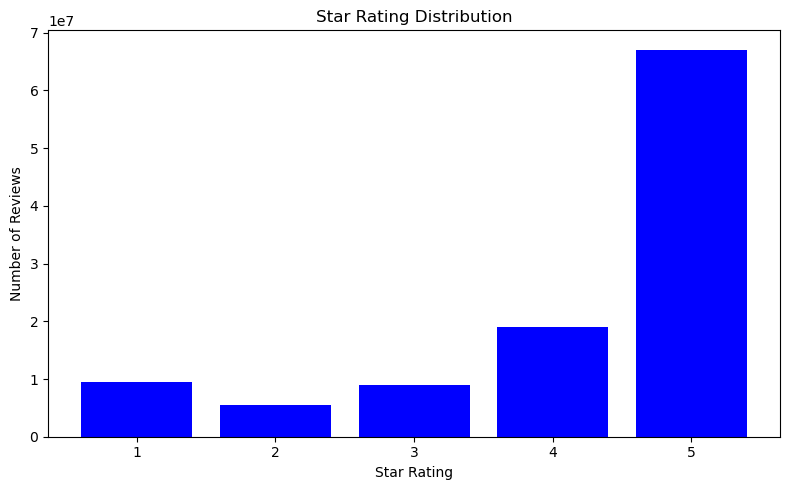

In [16]:
# Distribution of star rating
star_data = df.filter(col("star_rating").isin(["1","2","3","4","5"])) \
    .groupBy("star_rating") \
    .count() \
    .orderBy("star_rating") \
    .toPandas()

plt.figure(figsize=(8,5))
plt.bar(star_data["star_rating"], star_data["count"], color="blue")
plt.title("Star Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

This bar chart shows the distribution of star ratings across all 109M reviews. The distribution is heavily skewed toward 5 star ratings, which account for approximately 67 million reviews. 1 star reviews are the second most common at ~9.4 million, suggesting a J shaped distribution where people are most motivated to review when they are either very satisfied or very disappointed. This class imbalance will need to be addressed during preprocessing.

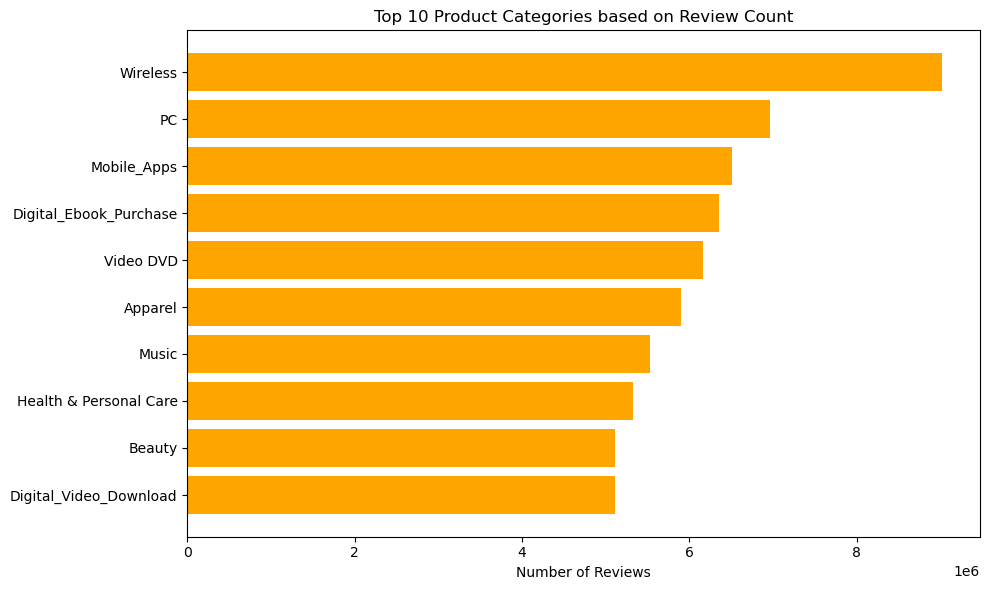

In [17]:
# Top 10 product categories by review count
cat_data = df.groupBy("product_category") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(10,6))
plt.barh(cat_data["product_category"], cat_data["count"], color="orange")
plt.title("Top 10 Product Categories based on Review Count")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


This horizontal bar chart shows the 10 most reviewed product categories. Wireless leads with ~9 million reviews, followed by PC and Mobile Apps. The distribution across categories is relatively uneven. Our analysis will need to account for this imbalance when comparing helpfulness across categories.

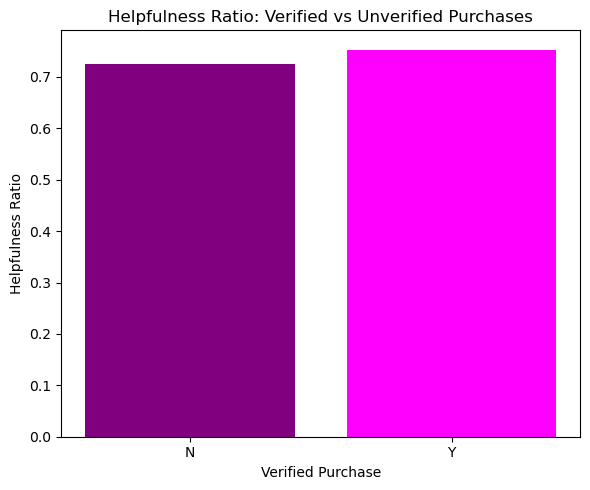

In [18]:
# Does helpfulness ratio between verfied and unverfied purchases result in a bias?
verified_data = df.filter(
    (col("total_votes") > 0) &
    (col("verified_purchase").isin(["Y", "N"]))
).groupBy("verified_purchase") \
    .agg(round(
        spark_sum(col("helpful_votes")) / spark_sum(col("total_votes")), 3
    ).alias("helpfulness_ratio")) \
    .orderBy("verified_purchase") \
    .toPandas()

plt.figure(figsize=(6,5))
plt.bar(verified_data["verified_purchase"], verified_data["helpfulness_ratio"], color=["purple", "magenta"])
plt.title("Helpfulness Ratio: Verified vs Unverified Purchases")
plt.xlabel("Verified Purchase")
plt.ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

This bar chart compares the average helpfulness ratio between verified (Y = 0.75) and unverified (N = 0.72) purchases. Verified purchasers have a slightly higher helpfulness ratio, suggesting that shoppers marginally trust reviews from people who actually bought the product. The difference is small but consistent across 109M rows, making it statistically meaningful.

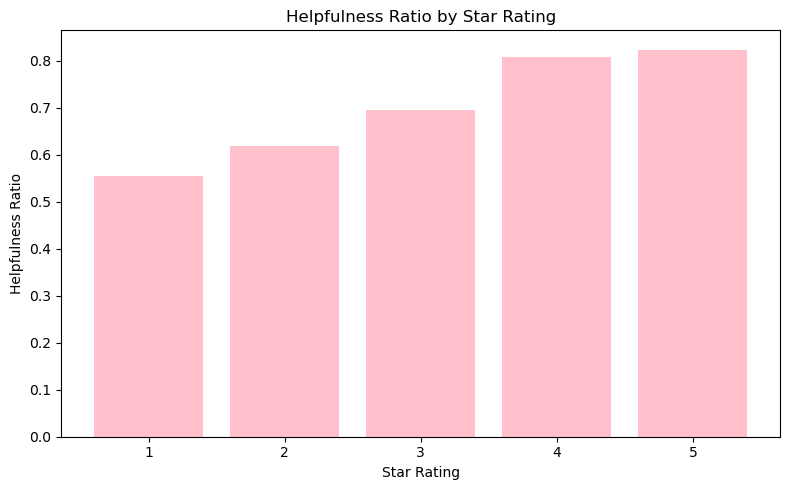

In [19]:
# Distribution of Star rating by helpfullness ratio
star_help = df.filter(
    (col("total_votes") > 0) &
    (col("star_rating").isin(["1","2","3","4","5"]))
).groupBy("star_rating") \
  .agg(round(
      spark_sum(col("helpful_votes")) / spark_sum(col("total_votes")), 3
  ).alias("helpfulness_ratio")) \
  .orderBy("star_rating") \
  .toPandas()

plt.figure(figsize=(8,5))
plt.bar(star_help["star_rating"], star_help["helpfulness_ratio"], color="pink")
plt.title("Helpfulness Ratio by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

This bar chart shows a clear positive trend where higher star ratings match higher helpfulness ratios. 5 star reviews have a helpfulness ratio of ~0.82, while 1 star reviews have the lowest at ~0.56. This suggests that positive reviews are generally found more useful by other shoppers, which is an important insight.

In [ ]:
# Does helpfulness ratio have an impact on review length?
length_data = df.filter(
    (col("total_votes") > 0) &
    (col("review_body").isNotNull())
).withColumn("review_length", length(col("review_body"))) \
    .filter(col("review_length") < 5000) \
    .groupBy("review_length") \
    .agg(round(
        spark_sum(col("helpful_votes")) / spark_sum(col("total_votes")), 3
    ).alias("helpfulness_ratio")) \
    .orderBy("review_length") \
    .toPandas()

length_data = length_data.sample(frac=0.01, random_state=42)

plt.figure(figsize=(10,5))
plt.scatter(length_data["review_length"], length_data["helpfulness_ratio"], alpha=0.3, s=5, color="black")
plt.title("Review Length vs Helpfulness Ratio")
plt.xlabel("Review Length (by characters)")
plt.ylabel("Helpfulness Ratio")
plt.tight_layout()
plt.show()

This scatter plot shows the relationship between review length in characters and helpfulness ratio, sampled from reviews with at least 1 vote. A clear positive trend is visible which implies longer reviews tend to receive higher helpfulness ratios. Reviews under 500 characters cluster around 0.68 to 0.75, while reviews approaching 5,000 characters reach helpfulness ratios of 0.85 to 0.93. This supports our hypothesis that review length is a meaningful predictor of perceived helpfulness.

In [ ]:
# Create a temporary table/view "reviews" for the spark dataframe
df.createOrReplaceTempView("reviews")

In [ ]:
# Average of helpfulness ratio by vine reviews.
vine_pdf = sqlContext.sql(
    """
    SELECT vine, ROUND(AVG(helpful_votes / total_votes), 4) as avg_ratio
    FROM reviews
    WHERE total_votes > 0
    GROUP BY vine
    ORDER BY vine
    """).toPandas()

colors = ['green', 'blue']
bars = plt.bar(vine_pdf['vine'], vine_pdf['avg_ratio'], color=colors, width=0.6)
plt.bar_label(bars, padding=3, fmt='%.4f')
plt.title('Average Helpfulness Ratio for Vine vs Non-Vine')
plt.xlabel('Vine Member (N = No, Y = Yes)')
plt.ylabel('Average Helpfulness Ratio')
plt.ylim(0, 1)
plt.show()

The plot shows a gradual decline in the average helpfulness ratio of Amazon reviews over time. While earlier reviews exhibit higher helpfulness, the ratio declines even as the review volume increases. The higher helpfulness scores could be due to a smaller and more engaged user base. This suggests that Amazon's growth introduces greater variability and more low-quality or low-engagement reviews, which reduces overall helpfulness.

In [ ]:
# Average helpfulness ration by year
ratio_time_pdf = sqlContext.sql(
    """
    SELECT YEAR(review_date) as year, ROUND(AVG(helpful_votes / total_votes), 4) as avg_ratio
    FROM reviews
    WHERE total_votes > 0 AND YEAR(review_date) BETWEEN 1995 AND 2015
    GROUP BY year
    ORDER BY year
    """).toPandas()

plt.plot(ratio_time_pdf['year'], ratio_time_pdf['avg_ratio'], marker='o')
plt.title('Average Helpfulness Ratio Per Year')
plt.xlabel('Year')
plt.ylabel('Average Helpfulness Ratio')
plt.xticks(ratio_time_pdf['year'][::2].astype(int), rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [ ]:
# Number of reviews by year.
time_pdf = sqlContext.sql(
    """
    SELECT YEAR(review_date) as year, COUNT(*) as count
    FROM reviews
    WHERE YEAR(review_date) BETWEEN 1950 AND 2026
    GROUP BY year
    ORDER BY year
    """).toPandas()

plt.plot(time_pdf['year'], time_pdf['count'], marker='o')
plt.xticks(time_pdf['year'][::2].astype(int), rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Number of Reviews Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

It’s possible that shoppers tend to trust reviewers who paid for the product instead of reviewers who received the product for free. That may explain why the reviews from non-vine reviewers received more helpful votes. 